## Rachel's Anomaly Plot of Day of Max Temp relative to baseline

In [191]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import scipy.stats as stats

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

### Load lSM for doing land vs ocean

In [104]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

### Load baseline period for climatology 1961-1990

In [106]:
%%time

# takes 51 sec to load

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm)
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1991,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 19.2 s, sys: 25.9 s, total: 45.1 s
Wall time: 51.7 s


<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 30)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 240B 1961-01-01 ... 1990-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerEnd     (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerTmax    (time, lat, lon) float64 249MB 179.0 179.0 ... 203.0 203.0
    SummerHeat    (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerLength  (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerRMSE    (time, lat, lon) float64 249MB 6.906 6.906 ... 5.745 5.745
    SummerR2      (time, lat, lon) float64 249MB 0.5105 0.5105 ... 0.6524 0.6524
    SummerMeanT   (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanHS  (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    lsm           (time, lat, lon) float64 249MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Determine average day of mean Tmax during baseline (1961-1990) for each grid cell and also standard deviation to calculate standard error

7

In [107]:
# used for standard error
num_yrs = len(ds_base.time)

mean_tmaxday_baseline = ds_base.SummerTmax.mean(dim='time')
se_tmaxday_baseline = ds_base.SummerTmax.std(dim='time')/np.sqrt(num_yrs)
mean_tmaxday_baseline, se_tmaxday_baseline

(<xarray.DataArray 'SummerTmax' (lat: 721, lon: 1440)> Size: 8MB
 array([[186.96666667, 186.96666667, 186.96666667, ..., 186.96666667,
         186.96666667, 186.96666667],
        [186.76666667, 186.76666667, 186.76666667, ..., 186.76666667,
         186.76666667, 186.76666667],
        [186.3       , 186.3       , 186.3       , ..., 186.6       ,
         186.3       , 186.3       ],
        ...,
        [199.2       , 199.2       , 199.2       , ..., 199.2       ,
         199.2       , 199.2       ],
        [198.26666667, 198.26666667, 198.23333333, ..., 198.26666667,
         198.26666667, 198.26666667],
        [198.6       , 198.6       , 198.6       , ..., 198.6       ,
         198.6       , 198.6       ]])
 Coordinates:
   * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8,
 <xarray.DataArray 'SummerTmax' (lat: 721, lon: 1440)> Size: 8MB
 array([[1.65561894, 1.65561894, 1.6556

### Load analysis period days: 1990-2023

In [176]:
%%time

# takes 63 sec to load

# start with one year and lsm and add a coordinate for the year
year = 1990
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1991,2024,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 24.9 s, sys: 35.5 s, total: 1min
Wall time: 1min 12s


<xarray.Dataset> Size: 3GB
Dimensions:       (lat: 721, lon: 1440, time: 34)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 272B 1990-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 282MB 146.0 146.0 ... 216.0 216.0
    SummerEnd     (time, lat, lon) float64 282MB 220.0 220.0 ... 247.0 247.0
    SummerTmax    (time, lat, lon) float64 282MB 174.0 174.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 282MB 663.9 663.9 ... 69.28 69.28
    SummerLength  (time, lat, lon) float64 282MB 75.0 75.0 75.0 ... 32.0 32.0
    SummerRMSE    (time, lat, lon) float64 282MB 7.937 7.937 ... 5.387 5.387
    SummerR2      (time, lat, lon) float64 282MB 0.5064 0.5064 ... 0.735 0.735
    SummerMeanT   (time, lat, lon) float64 282MB 245.3 245.3 ... 272.9 272.9
    SummerMeanHS  (time, lat, lon) float64 282MB 8.852 8.852 ... 2.165 2.165
    lsm           (time, lat, lon) float64 282MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

# Determine average day of mean Tmax during 1990-2023 for each grid cell and standard error of that mean

In [177]:
# used for standard error
num_yrs = len(ds.time)

mean_tmaxday_analysis = ds.SummerTmax.mean(dim='time')
se_tmaxday_analysis = ds.SummerTmax.std(dim='time')/np.sqrt(num_yrs)
mean_tmaxday_analysis, se_tmaxday_analysis

(<xarray.DataArray 'SummerTmax' (lat: 721, lon: 1440)> Size: 8MB
 array([[181.47058824, 181.47058824, 181.47058824, ..., 181.47058824,
         181.47058824, 181.47058824],
        [180.61764706, 180.61764706, 180.61764706, ..., 180.61764706,
         180.61764706, 180.61764706],
        [180.38235294, 180.38235294, 180.38235294, ..., 180.08823529,
         180.23529412, 180.38235294],
        ...,
        [203.20588235, 203.20588235, 203.20588235, ..., 203.29411765,
         203.29411765, 203.20588235],
        [203.32352941, 203.32352941, 203.32352941, ..., 203.35294118,
         203.35294118, 203.35294118],
        [203.61764706, 203.61764706, 203.61764706, ..., 203.61764706,
         203.61764706, 203.61764706]])
 Coordinates:
   * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8,
 <xarray.DataArray 'SummerTmax' (lat: 721, lon: 1440)> Size: 8MB
 array([[2.02161131, 2.02161131, 2.0216

## Use the SE for the baseline mean we can see where the error overlaps or not with the mean for the analysis period to get a hint of stat sig or not. If the mean analysis values $\pm$ analysis SE for 1990-2023 are higher or lower than the mean baseline $\pm$ baseline SE  then call it "significant"

In [178]:
mean_tmaxday_analysis_sig = mean_tmaxday_analysis.where(
    ((mean_tmaxday_analysis + se_tmaxday_analysis) < (mean_tmaxday_baseline - se_tmaxday_baseline)) |
    ((mean_tmaxday_analysis - se_tmaxday_analysis) > (mean_tmaxday_baseline + se_tmaxday_baseline))
)


mean_tmaxday_analysis_sig.attrs["long_name"] = "Day of Max Mean T2m"
mean_tmaxday_analysis_sig.attrs["units"] = "DOY"

mean_tmaxday_analysis_sig.count()

<xarray.DataArray 'SummerTmax' ()> Size: 8B
array(298420)

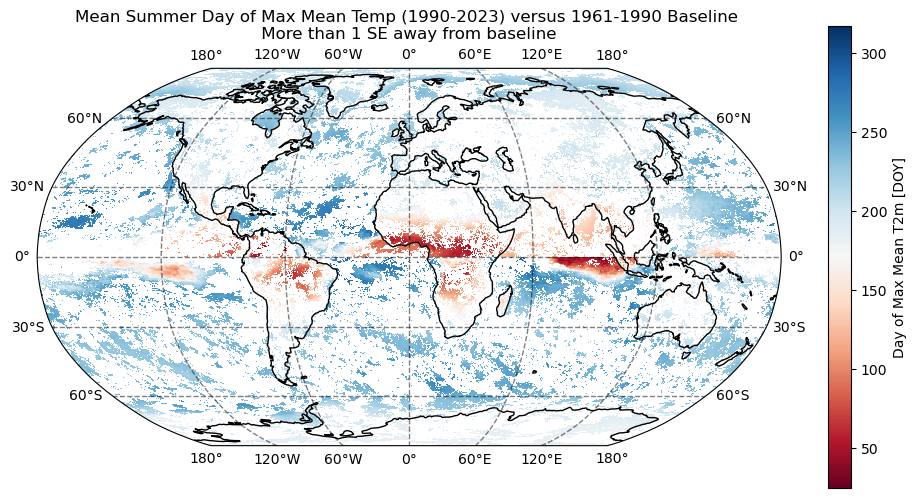

In [179]:


############
#Global map of tmax anomaly
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

mean_tmaxday_analysis_sig.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-50,
    #vmax=50, # define range to include an entire year
    cmap="RdBu"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Mean Summer Day of Max Mean Temp (1990-2023) versus 1961-1990 Baseline \n More than 1 SE away from baseline ")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



## Some Violins for distribution of Tmax Day in some locations

### Vancouver

In [180]:
input_lat = 49.246
input_lon = -123.116
van_tmax_analysis = ds.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")
van_tmax_base = ds_base.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")
van_tmax_analysis, van_tmax_base

(<xarray.DataArray 'SummerTmax' (time: 34)> Size: 272B
 array([223., 204., 225., 216., 203., 200., 207., 229., 208., 217., 179.,
        222., 204., 211., 205., 217., 203., 192., 227., 210., 190., 233.,
        217., 182., 223., 200., 231., 248., 211., 163., 229., 179., 208.,
        226.])
 Coordinates:
     lat      float64 8B 49.25
     lon      float64 8B -123.0
   * time     (time) datetime64[ns] 272B 1990-01-01 1991-01-01 ... 2023-01-01
 Attributes:
     long_name:  Day of max mean temp during summer for the year
     units:      Day of year,
 <xarray.DataArray 'SummerTmax' (time: 30)> Size: 240B
 array([194., 208., 252., 223., 213., 236., 228., 209., 169., 196., 211.,
        219., 209., 241., 208., 205., 229., 220., 198., 203., 222., 208.,
        212., 206., 201., 239., 180., 201., 175., 223.])
 Coordinates:
     lat      float64 8B 49.25
     lon      float64 8B -123.0
   * time     (time) datetime64[ns] 240B 1961-01-01 1962-01-01 ... 1990-01-01
 Attributes:
     long_name:  

### Sydney

In [224]:
# test for Sydney
input_lat = -33 - 52/60 - 4/3600
input_lon = 151.0 # a bit inland but need to avoid it landing on ocean
syd_tmax_analysis = ds.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")
syd_tmax_base = ds_base.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")

### Barcelona

In [182]:
input_lat = 41.38879000
input_lon = 2.15899000
bar_tmax_analysis = ds.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")
bar_tmax_base = ds_base.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")

### Santiago



In [183]:
input_lat = -33.45694000
input_lon = -70.64827000
san_tmax_analysis = ds.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")
san_tmax_base = ds_base.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")

### Nairobi

In [184]:
input_lat = -1.28333000
input_lon = 36.81667000
nai_tmax_analysis = ds.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")
nai_tmax_base = ds_base.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")

### Beijing

In [185]:
input_lat = 39.9075
input_lon = 116.39723
bei_tmax_analysis = ds.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")
bei_tmax_base = ds_base.SummerTmax.sel(lat=input_lat, lon=input_lon, method="nearest")

### Plot those histograms as violins

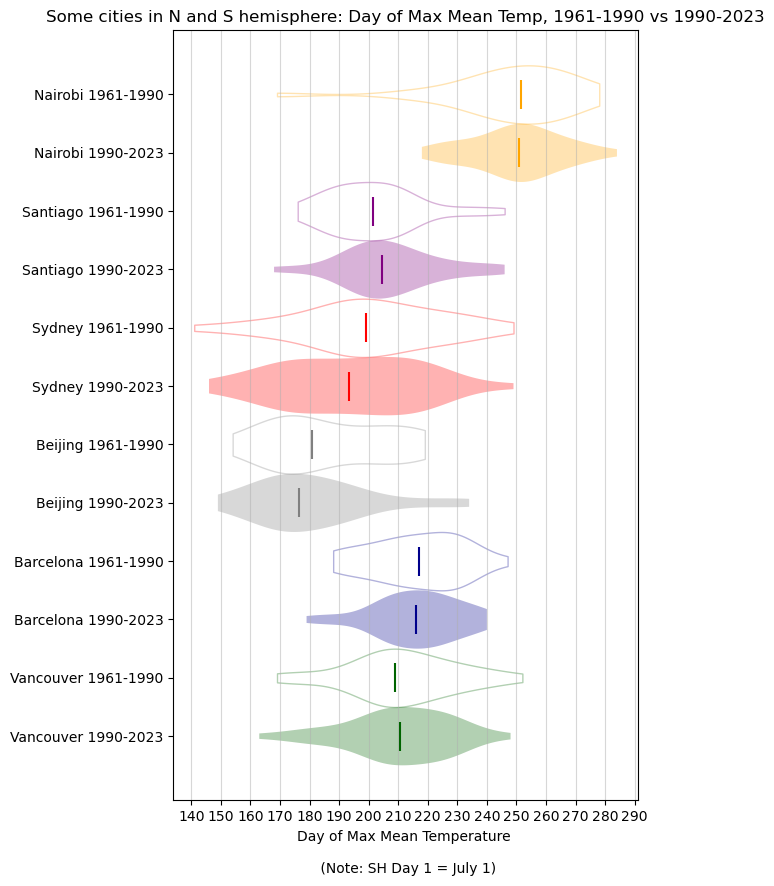

In [225]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Vancouver 1990-2023','Vancouver 1961-1990',
        'Barcelona 1990-2023','Barcelona 1961-1990',
        'Beijing 1990-2023','Beijing 1961-1990',
        'Sydney 1990-2023','Sydney 1961-1990',
        'Santiago 1990-2023','Santiago 1961-1990',
        'Nairobi 1990-2023','Nairobi 1961-1990'
        ]

colors = ['darkgreen','darkgreen','darkblue','darkblue','gray','gray','red','red','purple','purple','orange','orange']
data = [van_tmax_analysis, van_tmax_base, 
        bar_tmax_analysis, bar_tmax_base,
        bei_tmax_analysis, bei_tmax_base,
        syd_tmax_analysis, syd_tmax_base,
       san_tmax_analysis, san_tmax_base,
       nai_tmax_analysis, nai_tmax_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(6,10))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Day of Max Mean Temperature \n \n (Note: SH Day 1 = July 1)")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("Some cities in N and S hemisphere: Day of Max Mean Temp, 1961-1990 vs 1990-2023")
plt.show()


# Set up the figure and axis


# Create a list of the data to be plotted
#data = [data1, data2, data3]

# Set the colors for the violins based on the category
#colors = ['Blue', 'Green', 'Purple']

# Create the violin plot
#plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)

# Set the color of the violin patches
# for pc, color in zip(plots['bodies'], colors):
#     pc.set_facecolor(color)

# Set the color of the median lines
# plots['cmedians'].set_colors(colors)

# Set the labels
# ax1.set_yticks( labels=['category1', 'category2', 'category3'])

# ax1.invert_yaxis() # ranking from top to bottom: invert yaxis

# plt.show()

## Perform 2-sample t-test between baseline and analysis period for each grid cell and store the p-values so we can decorate the map when difference is significant at p < 0.05 level. This is a paired (related) t-test because it is the same location but at different times/years <br><br> t-test between 1961-1990 and 1994-2023 to have same size

In [205]:
# help from https://stackoverflow.com/questions/72988708/t-test-of-gridded-3-d-data-in-python

# first dim is time so by default the t-test is performed across time

analysis_tmax = ds.SummerTmax.sel(time=slice('1994','2023')).load().squeeze()
base_tmax = ds_base.SummerTmax.load().squeeze()
#analysis_tmax, base_tmax

statres, pval = stats.ttest_rel(analysis_tmax, base_tmax)
pval.shape, pval
 

((721, 1440),
 array([[0.11142798, 0.11142798, 0.11142798, ..., 0.11142798, 0.11142798,
         0.11142798],
        [0.04712646, 0.04712646, 0.04712646, ..., 0.04712646, 0.04712646,
         0.04712646],
        [0.0520293 , 0.0520293 , 0.0520293 , ..., 0.03273915, 0.0452715 ,
         0.0520293 ],
        ...,
        [0.31647603, 0.31647603, 0.31647603, ..., 0.30046368, 0.30046368,
         0.31647603],
        [0.24008493, 0.24008493, 0.23302995, ..., 0.2369865 , 0.2369865 ,
         0.2369865 ],
        [0.23636733, 0.23636733, 0.23636733, ..., 0.23636733, 0.23636733,
         0.23636733]]))

### Subtract for anomaly between analysis values that are "significant" and baseline and create map

In [210]:
tmax_anomaly = mean_tmaxday_analysis_sig - mean_tmaxday_baseline
tmax_anomaly.attrs["long_name"] = "Day of Year Difference"
tmax_anomaly.attrs["units"] = "Days"
ds_tmax_anom = tmax_anomaly.to_dataset(promote_attrs=True)
ds_tmax_anom

<xarray.Dataset> Size: 8MB
Dimensions:     (lat: 721, lon: 1440)
Coordinates:
  * lat         (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon         (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    SummerTmax  (lat, lon) float64 8MB -5.496 -5.496 -5.496 ... nan nan nan
Attributes:
    long_name:  Day of Year Difference
    units:      Days

### Can I copy in the p-vals on the anomaly data array?


In [213]:
# help from https://stackoverflow.com/questions/51196438/add-numpy-array-as-variable-to-xarray-dataset
ds_tmax_anom['Pval'] = (['lat','lon'], pval)
ds_tmax_anom

#data_set["Temperature"]=(['x', 'y', 'time'],  temp)

<xarray.Dataset> Size: 17MB
Dimensions:     (lat: 721, lon: 1440)
Coordinates:
  * lat         (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon         (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    SummerTmax  (lat, lon) float64 8MB -5.496 -5.496 -5.496 ... nan nan nan
    Pval        (lat, lon) float64 8MB 0.1114 0.1114 0.1114 ... 0.2364 0.2364
Attributes:
    long_name:  Day of Year Difference
    units:      Days

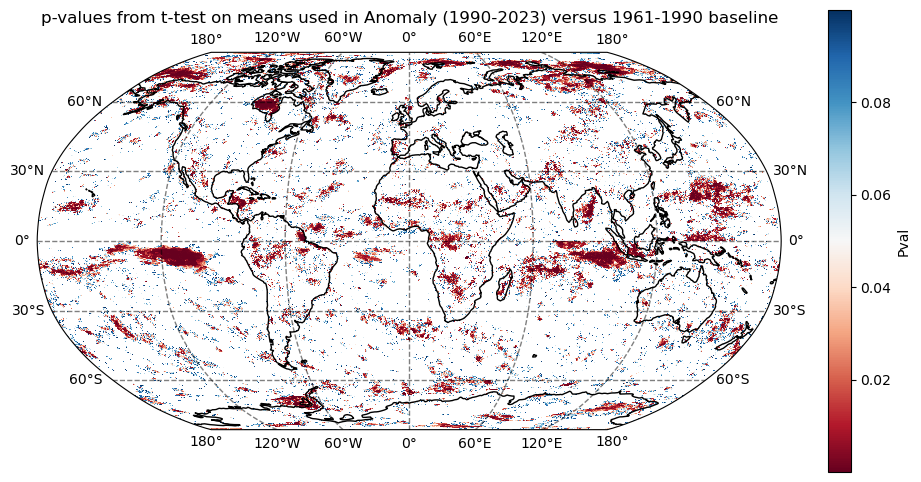

In [218]:
# p-value map

############
#Global map of tmax anomaly pvalues
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

ds_tmax_anom.Pval.where(ds_tmax_anom.Pval <= 0.10).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=0,
    #vmax=0.1, # define range to include an entire year
    cmap="RdBu"#"YlOrRd"#cmap="coolwarm"
)

plt.title("p-values from t-test on means used in Anomaly (1990-2023) versus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



## make maps of the significant data

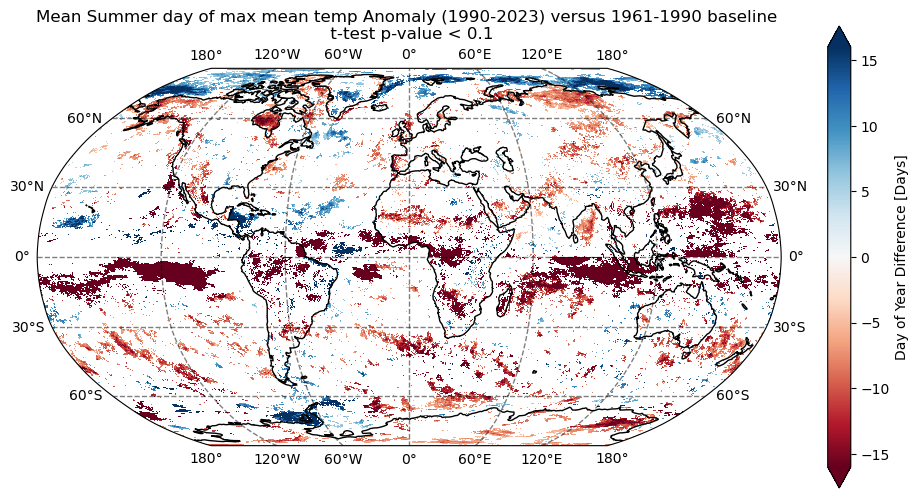

In [219]:


############
#Global map of tmax anomaly
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

ds_tmax_anom.SummerTmax.where(ds_tmax_anom.Pval <= 0.10).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-16,
    vmax=16, # define range to include an entire year
    cmap="RdBu"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Mean Summer day of max mean temp Anomaly (1990-2023) versus 1961-1990 baseline \n t-test p-value < 0.1")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



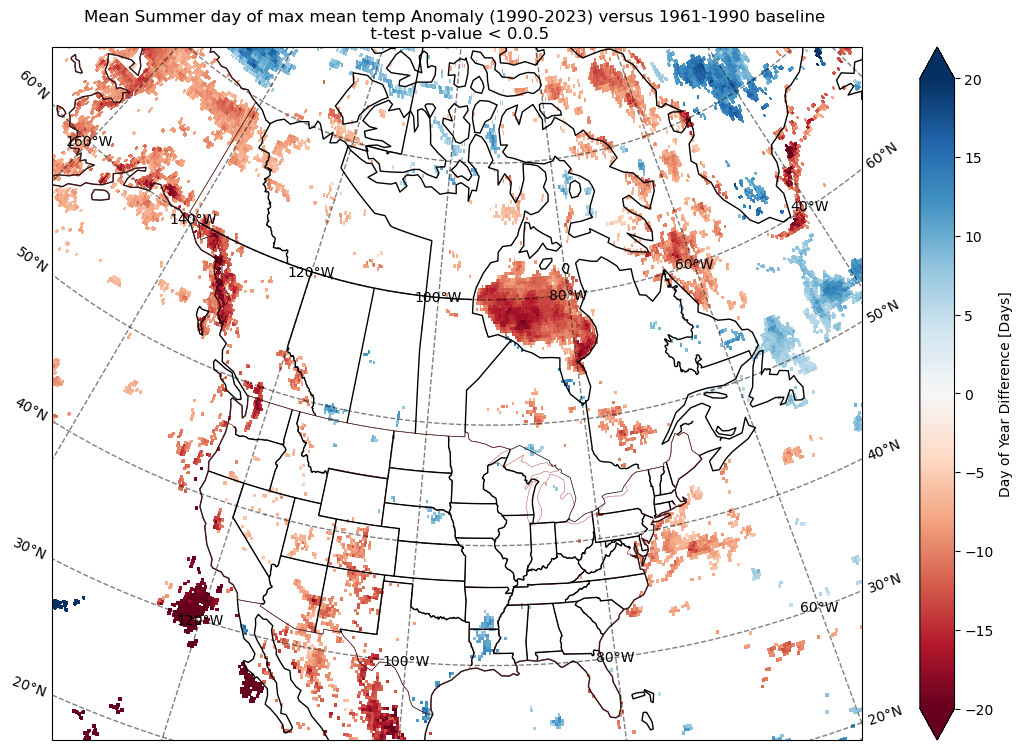

In [222]:

central_longitude = -(91 + 52 / 60)
central_latitude = 40

############
#Global map of tmax anomaly
fig = plt.figure(figsize=(15,9))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

dataplot = ds_tmax_anom.SummerTmax.where(ds_tmax_anom.Pval <= 0.05).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-20,
    vmax=20, # define range to include an entire year
    cmap="RdBu",#"YlOrRd"#cmap="coolwarm"
    
)
ax.set_extent((-130, -60, 20, 75))

provinces_50m = cfeature.NaturalEarthFeature('cultural',
                                             'admin_1_states_provinces_lines',
                                             '50m',
                                             facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(provinces_50m)


#plt.colorbar(dataplot,label="Day of year difference", pad=0.11)

#fig.colorbar(label="Day of year difference",              shrink=0.55, pad=0.11             )

plt.title("Mean Summer day of max mean temp Anomaly (1990-2023) versus 1961-1990 baseline \n t-test p-value < 0.0.5")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



## What about for Europe?

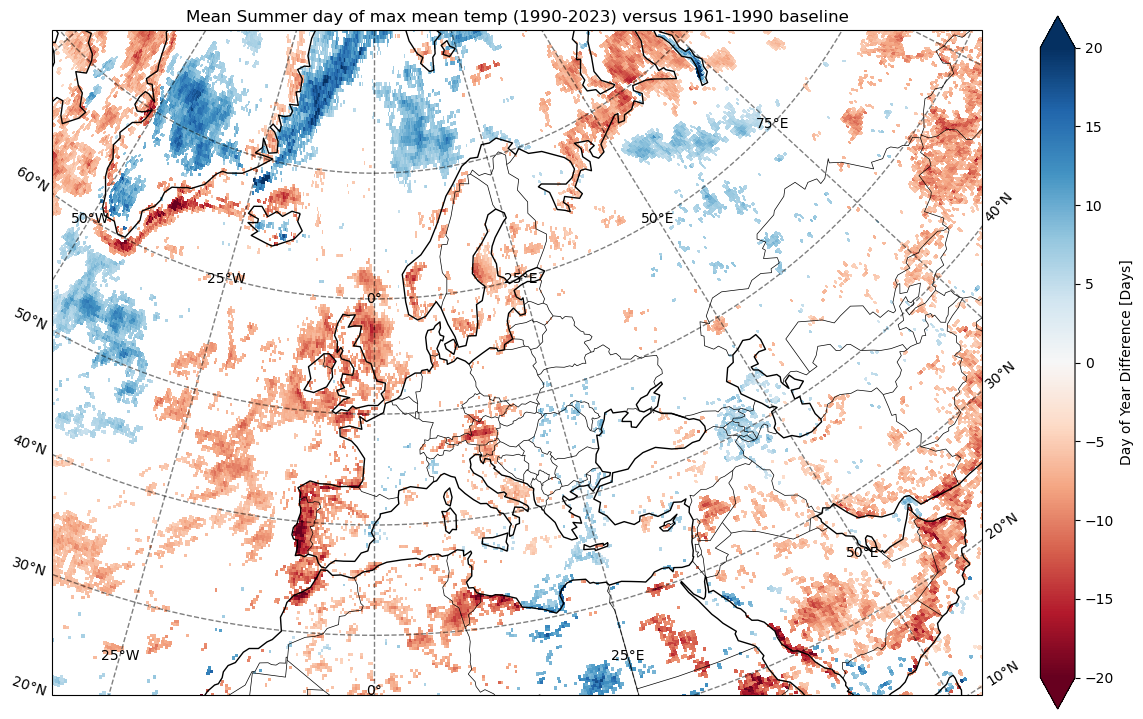

In [223]:

central_longitude = 0
central_latitude = 40

############
#Global map of tmax anomaly
fig = plt.figure(figsize=(15,9))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=central_longitude, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

dataplot = tmax_anomaly.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-20,
    vmax=20, # define range to include an entire year
    cmap="RdBu",#"YlOrRd"#cmap="coolwarm"
    
)
ax.set_extent((-30, 60, 20, 75))

# provinces_50m = cfeature.NaturalEarthFeature('cultural',
#                                              'admin_1_states_provinces_lines',
#                                              '50m',
#                                              facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
#ax.add_feature(provinces_50m)


#plt.colorbar(dataplot,label="Day of year difference", pad=0.11)

#fig.colorbar(label="Day of year difference",              shrink=0.55, pad=0.11             )

plt.title("Mean Summer day of max mean temp (1990-2023) versus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



## Try for around Australia

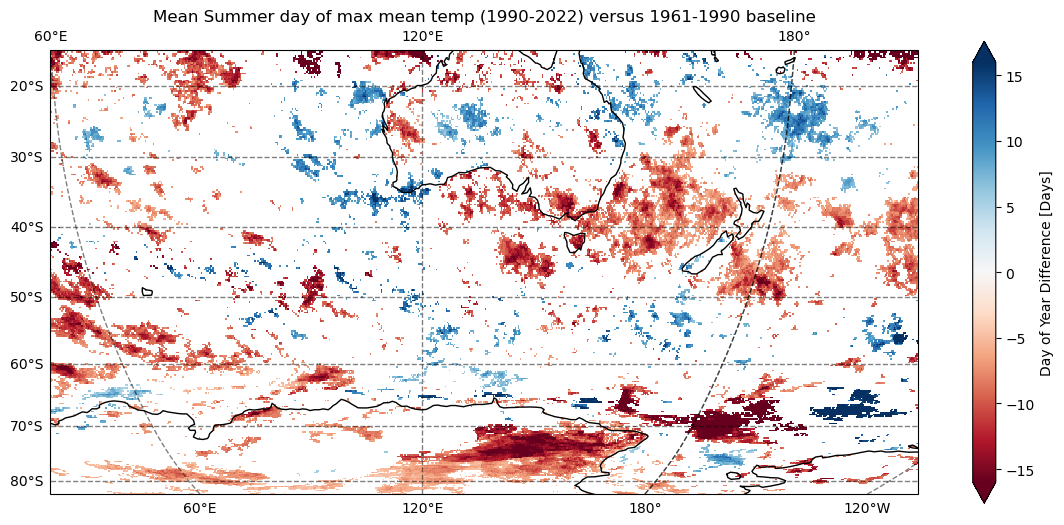

In [99]:

central_longitude = 120
central_latitude = -30

############
#Global map of tmax anomaly
fig = plt.figure(figsize=(14,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=central_longitude))#, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

dataplot = tmax_anomaly.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-16,
    vmax=16, # define range to include an entire year
    cmap="RdBu",#"YlOrRd"#cmap="coolwarm"
    
)
ax.set_extent((60, -160, -15, -70))

# provinces_50m = cfeature.NaturalEarthFeature('cultural',
#                                              'admin_1_states_provinces_lines',
#                                              '50m',
#                                              facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
#ax.add_feature(provinces_50m)


#plt.colorbar(dataplot,label="Day of year difference", pad=0.11)

#fig.colorbar(label="Day of year difference",              shrink=0.55, pad=0.11             )

plt.title("Mean Summer day of max mean temp (1990-2023) versus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()



## Asia

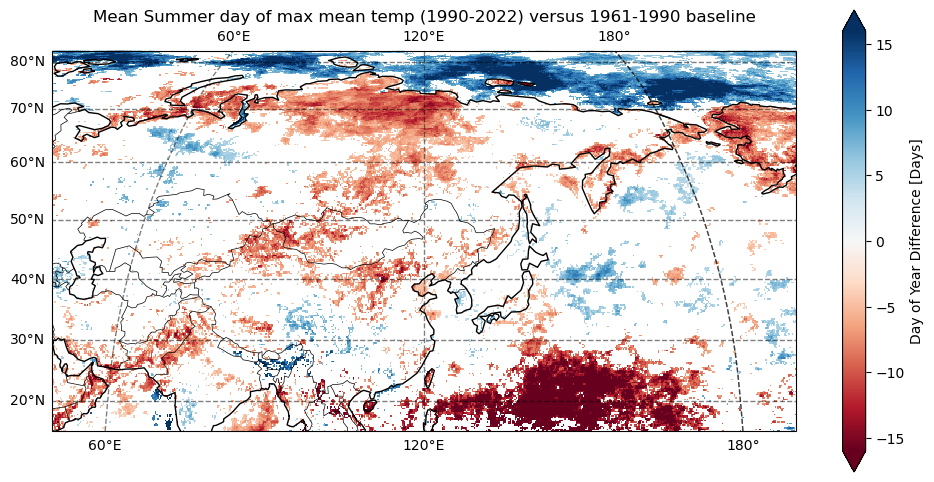

In [100]:

central_longitude = 120
central_latitude = -30

############
#Global map of tmax anomaly
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=central_longitude))#, central_latitude=central_latitude))

# add coastlines and grid
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')

dataplot = tmax_anomaly.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-16,
    vmax=16, # define range to include an entire year
    cmap="RdBu",#"YlOrRd"#cmap="coolwarm"
    
)
ax.set_extent((50, -170, 15, 70))

# provinces_50m = cfeature.NaturalEarthFeature('cultural',
#                                              'admin_1_states_provinces_lines',
#                                              '50m',
#                                              facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
#ax.add_feature(provinces_50m)


#plt.colorbar(dataplot,label="Day of year difference", pad=0.11)

#fig.colorbar(label="Day of year difference",              shrink=0.55, pad=0.11             )

plt.title("Mean Summer day of max mean temp (1990-2023) versus 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHeat_global.png")
plt.show()

